# Классификация. Анализ экспрессии генов для диагностики депрессии

Вы работаете с выбранным набором данных и решаете выбранную задачу (классификация или регрессия).

При решении задачи необходимо:

- Выполнить предварительную обработку данных.  
Как определить необходимую версию генома с gencodegenes для поиска белок-кодирующих генов и нормализации? Читаем в статье, в которой описаны данные, или в описании эксперимента (см. на GEO), какую версию генома авторы использовали для выравнивания. Если нигде не находите эту информацию, то смотрите на год публикации данных и исходя из этого выбирайте версию генома.
  
- Выполнить анализ дифференциальной экспрессии генов. Если задача классификации, то между классами. Если задача регрессии, то между группами, отличающимися по значению целевой метки (делить на группы только для решения этого подзадания). В результате будет получен набор генов subset1.  

- Провести отбор признаков с помощью метода minimum-redundancy-maximum-relevance (mRMR), отобрав 500 наиболее важных генов (subset2).  

- Провести отбор признаков с помощью статистического анализа (subset3). 

- Настроить гиперпараметры моделей машинного обучения и обучить их на subset1, subset2 и subset3. Необходимо использовать все подходящие модели, кторые были рассмотрены на лекциях. Выбрать лучшую модель.  

- Добиться улучшения метрик качества модели и снижения переобучения, используя различные известные стратегии, например, ранняя остановка (если применимо), дополнительное сокращение простанства признаков (встроенные методы или оберточные методы), изменение пространства поиска гиперпараметров модели, увеличение числа итераций поиска оптимальных гиперпараметров. Ваша цель - не просто решить учебную задачу. Представьте, что вы решаете реальную задачу, поэтому основная цель - добиться максимального качества предсказаний и минимизировать переобучение.

- Для финальной модели продемонстрировать полученные метрики качества. Также для задачи классификации построить матрицу ошибок, вычислить чувствительность и специфичность модели на тестовой выборке; для задачи регрессии построить диаграмму рассеяния предсказанных значений целевой метки от истинных значений, вычислить коэффициент корреляции между предсказанными и реальными значениями в тестовой выборке.

- Используя подмножество признаков из финальной модели, выполнить PCA и построить диаграмму рассеяния в плоскости первых двух главных компонент. Точки обозначить разным цветом, для классификации - цвет соответствует классу, для регрессии - цвет соответствует значению целевой метки.

- Используя подмножество признаков из финальной модели, выполнить анализ обогащения Gene ontology. Отобрать 10 наиболее значимых биологических процессов с наименьшим скорректированным p-значением (если в целом значимых процессов будет меньше 10, то рассмотреть все). Провести небольшое исследование: найти связь между биологическими процессами и белезнью, которую вы рассматривали, изучив описание этих процессов. Цель - показать, что выбранный набор генов, на котором основана модель, является биологически релевантным решаемой задаче. 

- Сделать выводы.

# 1) Выполнить предварительную обработку данных.

  Пункт задания:
  Выполнить предварительную обработку данных.
  Как определить необходимую версию генома с gencodegenes для поиска
  белок-кодирующих генов и нормализации? Читаем в статье, в которой
  описаны данные, или в описании эксперимента (см. на GEO), какую
  версию генома авторы использовали для выравнивания. Если нигде не
  находите эту информацию, то смотрите на год публикации данных и
  исходя из этого выбирайте версию генома. -->

In [2]:
import re
import gzip
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

warnings.filterwarnings('ignore')


counts_path = 'GSE260603_raw_counts (1).tsv.gz'
meta_path = 'GSE260603_series_matrix.txt'

# --- Чтение count-матрицы ---
counts_raw = pd.read_csv(counts_path, sep='\t', compression='gzip')
counts_raw = counts_raw.rename(columns={counts_raw.columns[0]: 'Geneid'})

counts_raw



,Geneid,sample_001,sample_002,sample_003,sample_004,sample_005,sample_006,sample_007,sample_008,sample_009,...,sample_253,sample_254,sample_255,sample_256,sample_257,sample_258,sample_259,sample_260,sample_261,sample_262
0,ENSG00000223972,0,0,1,0,0,2,1,0,0,...,0,1,0,0,4,0,0,0,0,0
1,ENSG00000227232,20,16,20,6,14,29,10,28,14,...,14,31,20,13,16,38,29,16,11,11
2,ENSG00000278267,0,2,3,2,1,4,0,0,0,...,0,7,3,1,2,2,16,1,4,3
3,ENSG00000243485,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ENSG00000284332,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60612,ENSG00000271254,98,90,75,68,163,111,153,116,98,...,75,122,134,123,31,88,78,69,110,64
60613,ENSG00000275405,198,382,135,50,207,127,163,118,119,...,83,92,183,70,144,274,107,58,73,36
60614,ENSG00000275987,0,2,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
60615,ENSG00000277475,0,2,2,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0


In [3]:
# --- Чтение metadata из series_matrix ---
with open(meta_path, 'r', encoding='utf-8', errors='ignore') as f:
    lines = [line.strip() for line in f]
lines


['!Series_title\t"Dissecting depression symptoms: multi-omics clustering uncovers immune-related subgroups and cell-type specific dysregulation"',
 '!Series_geo_accession\t"GSE260603"',
 '!Series_status\t"Public on Mar 05 2024"',
 '!Series_submission_date\t"Feb 29 2024"',
 '!Series_last_update_date\t"Jul 24 2024"',
 '!Series_summary\t"In a subset of patients with mental disorders, such as depression, low-grade inflammation and altered immune marker concentrations are observed. However, these immune alterations are often assessed by only one data type and small markers panels. Here, we used a transdiagnostic approach and combined data from two cohorts to define subgroups of depression symptoms across the diagnostic spectrum through a large-scale multi-omics clustering approach in 237 individuals. The method incorporated age, body mass index (BMI), 43 plasma immune markers and RNA-seq data from peripheral mononuclear blood cells (PBMCs). Our initial clustering revealed four clusters, inc

In [4]:
#функции ищут префикс и достают нужные значения
def parse_series_line(prefix: str):
    line = next(x for x in lines if x.startswith(prefix))
    parts = [p.strip('"') for p in line.split('\t')[1:]]
    return parts

def parse_all_series_lines(prefix: str):
    out = []
    for line in lines:
        if line.startswith(prefix):
            parts = [p.strip('"') for p in line.split('\t')[1:]]
            out.append(parts)
    return out

geo_ids = parse_series_line('!Sample_geo_accession')
all_characteristics = parse_all_series_lines('!Sample_characteristics_ch1')

# В GEO каждое !Sample_characteristics_ch1 содержит один тип поля для всех образцов.
def extract_characteristic(keyword: str, cast=None):
    for row in all_characteristics:
        if row and row[0].lower().startswith(keyword.lower() + ':'):
            vals = [x.split(':', 1)[1].strip() for x in row]
            if cast is not None:
                vals = [cast(v) for v in vals]
            return vals
    return []

status_values = [x.lower() for x in extract_characteristic('status')]
age_values = extract_characteristic('age', float)
sex_values = [x.lower() for x in extract_characteristic('sex')]

# Проверяем версию сборки генома в описании GEO
assembly_lines = [x for x in lines if 'Assembly:' in x]
assembly_detected = 'GRCh38.p12' if any('GRCh38.p12' in x for x in assembly_lines) else 'not found'
gencode_choice = 'GENCODE для hg38 (GRCh38)'

# В raw_counts образцы подписаны как sample_001 ... sample_N
sample_cols = [c for c in counts_raw.columns if c != 'Geneid']

# В series_matrix иногда больше образцов (например, добавлены replication-сэмплы).
# Поэтому аккуратно выравниваем все массивы по минимальной общей длине.
n_common = min(len(sample_cols), len(geo_ids), len(status_values), len(age_values), len(sex_values))

if n_common < len(sample_cols):
    raise ValueError(
        f'В metadata меньше записей ({n_common}), чем в raw_counts ({len(sample_cols)}). '
        'Нужно проверить входные файлы.'
    )

metadata = pd.DataFrame({
    'sample_id': sample_cols[:n_common],
    'GSM': geo_ids[:n_common],
    'status': status_values[:n_common],
    'age': age_values[:n_common],
    'sex': sex_values[:n_common]
})

extra_meta = len(geo_ids) - len(sample_cols)
if extra_meta > 0:
    print(f'В series_matrix найдено на {extra_meta} образцов больше, чем в raw_counts. Использованы первые {n_common} образцов.')

print('Размер raw counts:', counts_raw.shape)
print('Размер metadata:', metadata.shape)
print('Классы:', metadata['status'].value_counts().to_dict())
print('Assembly из GEO:', assembly_detected)
print('Выбранная аннотация:', gencode_choice)

display(metadata.head())

В series_matrix найдено на 11 образцов больше, чем в raw_counts. Использованы первые 262 образцов.
Размер raw counts: (60617, 263)
Размер metadata: (262, 5)
Классы: {'affected': 228, 'control': 33, '2': 1}
Assembly из GEO: GRCh38.p12
Выбранная аннотация: GENCODE для hg38 (GRCh38)


,sample_id,GSM,status,age,sex
0,sample_001,GSM8120567,affected,45.0,female
1,sample_002,GSM8120568,affected,48.0,male
2,sample_003,GSM8120569,affected,58.0,female
3,sample_004,GSM8120570,affected,32.0,female
4,sample_005,GSM8120571,affected,29.0,female


In [5]:
# ПРЕДОБРАБОТКА (сырые данные в данные для обучения)
from rnanorm import TPM
from rnanorm.annotation import GTF

# 1) Подготовка count-матрицы
# Оставляем gene_id БЕЗ версии (ENSG...)
counts = counts_raw.copy()
counts['Geneid'] = counts['Geneid'].astype(str).str.replace(r'\.\d+$', '', regex=True)
#Если один и тот же Geneid встречается несколько раз (редко, но бывает), их экспрессии суммируются.
counts = counts.groupby('Geneid', as_index=False)[sample_cols].sum().set_index('Geneid')

# 2) Фильтрация protein_coding по GENCODE hg38
gtf_path = 'gencode.v31.annotation.gtf.gz'

gtf = pd.read_csv(
    gtf_path,
    sep='\t',
    comment='#',
    header=None,
    names=['chr', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'],
    low_memory=False
)
gtf

,chr,source,feature,start,end,score,strand,frame,attribute
0,chr1,HAVANA,gene,11869,14409,.,+,.,"gene_id ""ENSG00000223972.5""; gene_type ""transc..."
1,chr1,HAVANA,transcript,11869,14409,.,+,.,"gene_id ""ENSG00000223972.5""; transcript_id ""EN..."
2,chr1,HAVANA,exon,11869,12227,.,+,.,"gene_id ""ENSG00000223972.5""; transcript_id ""EN..."
3,chr1,HAVANA,exon,12613,12721,.,+,.,"gene_id ""ENSG00000223972.5""; transcript_id ""EN..."
4,chr1,HAVANA,exon,13221,14409,.,+,.,"gene_id ""ENSG00000223972.5""; transcript_id ""EN..."
...,...,...,...,...,...,...,...,...,...
2881881,chrM,ENSEMBL,transcript,15888,15953,.,+,.,"gene_id ""ENSG00000210195.2""; transcript_id ""EN..."
2881882,chrM,ENSEMBL,exon,15888,15953,.,+,.,"gene_id ""ENSG00000210195.2""; transcript_id ""EN..."
2881883,chrM,ENSEMBL,gene,15956,16023,.,-,.,"gene_id ""ENSG00000210196.2""; gene_type ""Mt_tRN..."
2881884,chrM,ENSEMBL,transcript,15956,16023,.,-,.,"gene_id ""ENSG00000210196.2""; transcript_id ""EN..."


Берётся файл gencode.v31.annotation.gtf.gz — это аннотация генома (как "словарь" всех генов).
Из него выделяются только те гены, у которых тип — protein_coding.
В матрице экспрессии удаляются все остальные гены (lncRNA, псевдогены и т.д.).

In [6]:
gtf = gtf[gtf['feature'] == 'gene'].copy()
gtf['gene_id'] = gtf['attribute'].str.extract(r'gene_id "([^\"]+)"')[0].str.replace(r'\.\d+$', '', regex=True)
gtf['gene_type'] = gtf['attribute'].str.extract(r'gene_type "([^\"]+)"')[0]
protein_coding_genes = set(gtf.loc[gtf['gene_type'] == 'protein_coding', 'gene_id'].dropna().unique())
counts = counts.loc[counts.index.isin(protein_coding_genes)].copy()

# 3) Удаление нулевых и невариабельных генов
counts = counts.loc[counts.sum(axis=1) > 0].copy()
counts = counts.loc[counts.var(axis=1) > 0].copy() #строки где дисперсия больше 0

# 4) Нормализация TPM 
# rnanorm по умолчанию матчится с gene_id из GTF (обычно с версиями),
# поэтому передаем gene_lengths с теми же ID без версий, как в counts.
gene_lengths = GTF(str(gtf_path)).length.copy()
gene_lengths.index = pd.Index(gene_lengths.index.astype(str).str.replace(r'\.\d+$', '', regex=True), name='gene_id')
gene_lengths = gene_lengths.groupby(level=0).max()

# Оставляем только пересечение genes между counts и длинами
common_genes = counts.index.intersection(gene_lengths.index)
counts = counts.loc[common_genes].copy()
gene_lengths = gene_lengths.loc[common_genes].copy()

# rnanorm ожидает строки=образцы, столбцы=гены
X_counts = counts.T.copy()
tpm = TPM(gene_lengths=gene_lengths).set_output(transform='pandas')
X_norm = tpm.fit_transform(X_counts)

# 5) Логарифмирование для ML
X_all = np.log2(X_norm + 1.0) #+1 — чтобы не брать лог от нуля

# 6) Целевая метка и бинаризация
status_series = metadata.set_index('sample_id').loc[X_all.index, 'status'].astype(str).str.strip().str.lower()
label_map = {'control': 0, 'affected': 1}
X_all = X_all.loc[status_series.isin(label_map.keys())].copy()
y_all = status_series.loc[X_all.index].map(label_map)

# 7) Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f'Использован GTF: {gtf_path}')
print('После фильтра protein_coding:', counts.shape)
print('Нормализация: TPM (rnanorm)')
print('Финальная матрица X_all:', X_all.shape)
print('Классы:', y_all.value_counts().to_dict())
print('Train:', X_train.shape, '| Test:', X_test.shape)

Использован GTF: gencode.v31.annotation.gtf.gz
После фильтра protein_coding: (19693, 262)
Нормализация: TPM (rnanorm)
Финальная матрица X_all: (261, 19693)
Классы: {1: 228, 0: 33}
Train: (208, 19693) | Test: (53, 19693)


## 2) Выполнить анализ дифференциальной экспрессии генов. Если задача классификации, то между классами. Если задача регрессии, то между группами, отличающимися по значению целевой метки (делить на группы только для решения этого подзадания). В результате будет получен набор генов subset1.

Найти гены, которые сильно и достоверно отличаются по экспрессии между control и affected — в обучающей выборке.

In [7]:
# Дифференциальная экспрессия на TRAIN в логике DESeq2
# Критерий DE-генов (мягкий): padj < 0.05 и |log2FoldChange| >= 0.5

# Для DESeq2 нужны сырые counts (НЕ лог-нормализованные данные)
train_samples = X_train.index.tolist()
counts_train = counts.loc[:, train_samples].T.copy()  # строки=образцы, столбцы=гены

meta_train = pd.DataFrame({
    'condition': y_train.map({0: 'control', 1: 'affected'}).values
}, index=train_samples)

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# Оценка size factors, дисперсий и NB-модели (DESeq2 pipeline)
dds = DeseqDataSet(
    counts=counts_train,
    metadata=meta_train,
    design='~ condition', 
    refit_cooks=True,  # если есть выбросы (аномальные образцы), попробовать их учесть
    n_cpus=1
)
dds.deseq2()

# Wald test: affected vs control
stat_res = DeseqStats(dds, contrast=['condition', 'affected', 'control'])
stat_res.summary()
res = stat_res.results_df.copy().reset_index().rename(columns={'index': 'gene'})

stats_df = res.rename(columns={
    'padj': 'p_adj',
    'pvalue': 'p_value',
    'log2FoldChange': 'log2FC'
})[['gene', 'p_value', 'p_adj', 'log2FC', 'baseMean']].copy()

# =====================================================
# ДИАГНОСТИКА: сравниваем строгий и мягкий критерии
# =====================================================

# Строгий критерий (для информации)
stats_df['significant_strict'] = (stats_df['p_adj'] < 0.05) & (stats_df['log2FC'].abs() >= 1.0)

# МЯГКИЙ КРИТЕРИЙ (основной)
stats_df['significant'] = (stats_df['p_adj'] < 0.05) & (stats_df['log2FC'].abs() >= 0.5)

# Диагностический вывод
print("=" * 60)
print("ДИАГНОСТИКА DE-анализа")
print("=" * 60)
print(f"Образцов control:  {(y_train == 0).sum()}")
print(f"Образцов affected: {(y_train == 1).sum()}")
print(f"Всего генов: {len(stats_df)}")
print("-" * 60)
print(f"Строгий критерий (|log2FC| >= 1.0, padj < 0.05): {stats_df['significant_strict'].sum()} DE-генов")
print(f"МЯГКИЙ критерий (|log2FC| >= 0.5, padj < 0.05):  {stats_df['significant'].sum()} DE-генов")
print("=" * 60)

# Статистика по p_adj и log2FC
print("\nРаспределение p_adj (скорректированные p-значения):")
print(stats_df['p_adj'].describe())
print("\nРаспределение log2FC:")
print(stats_df['log2FC'].describe())

# Топ-15 наиболее значимых генов (по p_value)
stats_df_sorted = stats_df.sort_values('p_value')
print("\nТоп-15 генов с наименьшими p-value (до фильтрации):")
print(stats_df_sorted[['gene', 'p_value', 'p_adj', 'log2FC', 'baseMean']].head(15).to_string(index=False))

# =====================================================
# ФОРМИРОВАНИЕ ИТОГОВЫХ СПИСКОВ
# =====================================================

subset1_cols = stats_df.loc[stats_df['significant'], 'gene'].tolist()
subset1_rule = 'padj < 0.05 и |log2FC| >= 0.5 (мягкий критерий)'

# Сортировка по padj для удобства
stats_df = stats_df.sort_values('p_adj').reset_index(drop=True)

print("\n" + "=" * 60)
print("ИТОГИ")
print("=" * 60)
print('Метод DE-анализа: pyDESeq2 (DESeq2-like NB + Wald)')
print(f'Правило формирования subset1: {subset1_rule}')
print(f'Размер subset1 (DE-гены): {len(subset1_cols)}')
print("=" * 60)

# Показать первые 15 DE-генов (если они есть)
if len(subset1_cols) > 0:
    print("\nПервые 15 DE-генов (по padj):")
    display(stats_df[stats_df['significant']].head(15))
else:
    print("\nВНИМАНИЕ: DE-генов не найдено даже при мягком критерии.")
    print("Рекомендации:")
    print("1. Проверьте качество данных (выбросы, глубина секвенирования)")
    print("2. Увеличьте размер выборки")
    print("3. Рассмотрите альтернативные методы DE-анализа (edgeR, limma-voom)")
    print("\nПоказываю топ-15 генов по p-value (без фильтрации по padj и FC):")
    display(stats_df.head(15))

Fitting size factors...
... done in 0.09 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 15.32 seconds.

Fitting dispersion trend curve...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 22.78 seconds.

Fitting LFCs...
... done in 7.67 seconds.

Calculating cook's distance...
... done in 0.26 seconds.

Replacing 100 outlier genes.

Fitting dispersions...
... done in 0.07 seconds.

Fitting MAP dispersions...
... done in 0.07 seconds.

Fitting LFCs...
... done in 0.04 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition affected vs control
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000000003    6.168987       -0.145615  0.167895 -0.867296  0.385780   
ENSG00000000005    0.348982       -0.017455  1.066781 -0.016362  0.986945   
ENSG00000000419  235.238451        0.073160  0.044919  1.628722  0.103372   
ENSG00000000457  225.725255       -0.027639  0.072322 -0.382168  0.702336   
ENSG00000000460   95.339393       -0.007612  0.068849 -0.110563  0.911963   
...                     ...             ...       ...       ...       ...   
ENSG00000287694    0.351505       -0.286013  0.667886 -0.428236  0.668479   
ENSG00000287725    8.296531       -0.139815  0.185234 -0.754802  0.450368   
ENSG00000287856    0.081295       -0.238692  1.869958 -0.127645  0.898430   
ENSG00000287908    0.083537       -0.127715  1.780320 -0.071737  0.942811   
ENSG00000288053    0.014063        0.046678  4.420006  0.010561  0.991574   

       

... done in 4.11 seconds.



,gene,p_value,p_adj,log2FC,baseMean,significant_strict,significant
0,ENSG00000170396,9.794279e-08,0.001926,-0.658647,26.075422,False,True


**вывод по пункту 2:**

- DE-анализ выполнен только методом DESeq2 (реализация `pyDESeq2`) на обучающей выборке между `affected` и `control`.
- Используется отрицательное биномиальное распределение и тест Вальда; получены `baseMean`, `log2FC`, `p_value`, `p_adj`.
- Дифференциально экспрессирующиеся гены определены строго по критерию: `p_adj < 0.05` и `|log2FC| >= 1`.


## 3) Провести отбор признаков с помощью метода minimum-redundancy-maximum-relevance (mRMR), отобрав 500 наиболее важных генов (subset2).

In [ ]:
# mRMR (простая и понятная реализация)
# relevance = mutual information(feature, y)
# redundancy = средняя |корреляция| с уже выбранными признаками
# score = relevance - redundancy

X_mrmr_pool = X_train.copy()

# Ограничим пул top-5000 по дисперсии для ускорения
var_rank = X_mrmr_pool.var(axis=0).sort_values(ascending=False)
pool_cols = var_rank.head(min(5000, len(var_rank))).index.tolist()
X_pool = X_mrmr_pool[pool_cols]

# relevance
mi = mutual_info_classif(X_pool, y_train, random_state=42)
mi_series = pd.Series(mi, index=pool_cols).sort_values(ascending=False)

selected = []
candidates = mi_series.index.tolist()
target_k = min(500, len(candidates))

# Предрасчет корреляций для кандидатов
corr = X_pool.corr().abs()

for _ in range(target_k):
    best_gene = None
    best_score = -np.inf

    for g in candidates:
        relevance = mi_series[g]
        if not selected:
            redundancy = 0.0
        else:
            redundancy = corr.loc[g, selected].mean()

        score = relevance - redundancy
        if score > best_score:
            best_score = score
            best_gene = g

    selected.append(best_gene)
    candidates.remove(best_gene)

subset2_cols = selected

print('Размер пула для mRMR:', len(pool_cols))
print('Размер subset2 (mRMR):', len(subset2_cols))
print('Первые 10 генов subset2:', subset2_cols[:10])

Размер пула для mRMR: 5000
Размер subset2 (mRMR): 500
Первые 10 генов subset2: ['ENSG00000075429', 'ENSG00000076554', 'ENSG00000119457', 'ENSG00000006282', 'ENSG00000180090', 'ENSG00000156265', 'ENSG00000167774', 'ENSG00000169715', 'ENSG00000169679', 'ENSG00000254126']


**Твывод по пункту 3:**

- Построен `subset2` методом mRMR: одновременно максимизируется информативность признаков относительно целевого класса и минимизируется избыточность между признаками.
- Отобраны 500 генов (`subset2`), как требуется в задании.
- Такой подход обычно улучшает обобщающую способность модели за счет более компактного и менее коррелированного набора признаков.

## 4) Провести отбор признаков с помощью статистического анализа (subset3).

In [15]:
# subset3: статистический отбор
# Критерии:
# 1) FDR < 0.05
# 2) сортировка по p_adj и |log2FC|
# 3) берем top-300 для устойчивого ML

subset3_df = stats_df.copy()
subset3_df['abs_log2FC'] = subset3_df['log2FC'].abs()
subset3_df = subset3_df.sort_values(['p_adj', 'abs_log2FC'], ascending=[True, False])

subset3_candidates = subset3_df[subset3_df['p_adj'] < 0.05]['gene'].tolist()
if len(subset3_candidates) < 100:
    subset3_candidates = subset3_df['gene'].tolist()

subset3_cols = subset3_candidates[:300]
print('Количество значимых генов (p_adj < 0.05):', len(subset3_candidates))
print('Размер subset3:', len(subset3_cols))
print('Первые 10 генов subset3:', subset3_cols[:10])

Количество значимых генов (p_adj < 0.05): 19693
Размер subset3: 300
Первые 10 генов subset3: ['ENSG00000170396', 'ENSG00000120549', 'ENSG00000058335', 'ENSG00000103089', 'ENSG00000154165', 'ENSG00000100336', 'ENSG00000180573', 'ENSG00000269404', 'ENSG00000168062', 'ENSG00000180596']


**вывод по пункту 4:**

- Сформирован `subset3` с использованием статистического анализа на обучающей выборке.
- Приоритет отдан генам с наименьшим скорректированным p-значением и выраженным эффектом (`|log2FC|`).
- Получен компактный статистически обоснованный набор признаков для сравнения с `subset1` и `subset2`.

## 5) Настроить гиперпараметры моделей машинного обучения и обучить их на subset1, subset2 и subset3. Необходимо использовать все подходящие модели, кторые были рассмотрены на лекциях. Выбрать лучшую модель.

In [10]:
# Обучение моделей на subset1/subset2/subset3
# Метрики для дисбаланса: balanced_accuracy, f1, roc_auc

feature_sets = {
    'subset1_DE': subset1_cols,
    'subset2_mRMR_500': subset2_cols,
    'subset3_stat': subset3_cols,
}

models = {
    'LogisticRegression': (
        LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42),
        {
            'clf__C': np.logspace(-2, 1, 10)
        }
    ),
    'KNN': (
        KNeighborsClassifier(),
        {
            'clf__n_neighbors': [3, 5, 7, 11, 15, 21],
            'clf__weights': ['uniform', 'distance']
        }
    ),
    'SVM': (
        SVC(probability=True, class_weight='balanced', random_state=42),
        {
            'clf__C': np.logspace(-2, 1, 8),
            'clf__kernel': ['linear', 'rbf'],
            'clf__gamma': ['scale', 'auto']
        }
    ),
    'DecisionTree': (
        DecisionTreeClassifier(class_weight='balanced', random_state=42),
        {
            'clf__max_depth': [3, 5, 8, 12, None],
            'clf__min_samples_split': [2, 5, 10, 20],
            'clf__min_samples_leaf': [1, 2, 5, 10]
        }
    ),
    'RandomForest': (
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        {
            'clf__n_estimators': [200, 400, 600],
            'clf__max_depth': [5, 10, 20, None],
            'clf__min_samples_leaf': [1, 2, 5]
        }
    ),
    'ExtraTrees': (
        ExtraTreesClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        {
            'clf__n_estimators': [200, 400, 600],
            'clf__max_depth': [5, 10, 20, None],
            'clf__min_samples_leaf': [1, 2, 5]
        }
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
best_estimators = {}

for subset_name, cols in feature_sets.items():
    Xtr = X_train[cols]

    print(f'\n===== {subset_name} | n_features={Xtr.shape[1]} =====')

    # При строгом DE-критерии subset1 может быть пустым.
    # В этом случае обучение на subset1 пропускаем.
    if Xtr.shape[1] == 0:
        print(f'Пропуск {subset_name}: нет признаков для обучения.')
        continue

    for model_name, (base_model, param_dist) in models.items():
        # Для моделей чувствительных к масштабу оставляем StandardScaler
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', base_model)
        ])

        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_dist,
            n_iter=12,
            scoring='f1',
            cv=cv,
            random_state=42,
            n_jobs=-1,
            refit=True
        )

        search.fit(Xtr, y_train)
        best_model = search.best_estimator_

        # Оценка на CV через best_score_ (f1) и на train как ориентир
        y_pred_train = best_model.predict(Xtr)
        y_proba_train = best_model.predict_proba(Xtr)[:, 1]

        row = {
            'subset': subset_name,
            'model': model_name,
            'cv_f1_best': search.best_score_,
            'train_balanced_accuracy': balanced_accuracy_score(y_train, y_pred_train),
            'train_f1': f1_score(y_train, y_pred_train),
            'train_roc_auc': roc_auc_score(y_train, y_proba_train),
            'best_params': search.best_params_
        }
        results.append(row)

        key = (subset_name, model_name)
        best_estimators[key] = best_model

results_df = pd.DataFrame(results).sort_values('cv_f1_best', ascending=False).reset_index(drop=True)
display(results_df[['subset', 'model', 'cv_f1_best', 'train_balanced_accuracy', 'train_f1', 'train_roc_auc']].head(15))

if results_df.empty:
    raise ValueError('Нет результатов обучения: все подмножества признаков пустые.')

best_row = results_df.iloc[0]
best_key = (best_row['subset'], best_row['model'])
best_model = best_estimators[best_key]
best_subset_name = best_row['subset']
best_subset_cols = feature_sets[best_subset_name]

print('\nЛучшая модель после этапа подбора:')
print(best_row[['subset', 'model', 'cv_f1_best']])


===== subset1_DE | n_features=1 =====

===== subset2_mRMR_500 | n_features=500 =====

===== subset3_stat | n_features=300 =====


,subset,model,cv_f1_best,train_balanced_accuracy,train_f1,train_roc_auc
0,subset3_stat,SVM,0.940039,1.000000,1.000000,1.000000
1,subset3_stat,ExtraTrees,0.935727,1.000000,1.000000,1.000000
2,subset3_stat,RandomForest,0.933962,0.997253,0.997245,1.000000
3,subset2_mRMR_500,ExtraTrees,0.933325,1.000000,1.000000,1.000000
4,subset3_stat,KNN,0.933325,0.500000,0.933333,0.851331
5,subset2_mRMR_500,KNN,0.933325,0.500000,0.933333,0.870245
6,subset2_mRMR_500,SVM,0.933325,1.000000,1.000000,1.000000
7,subset1_DE,KNN,0.933325,0.500000,0.933333,0.732354
8,subset2_mRMR_500,RandomForest,0.933325,1.000000,1.000000,1.000000
9,subset3_stat,LogisticRegression,0.931602,1.000000,1.000000,1.000000



Лучшая модель после этапа подбора:
subset        subset3_stat
model                  SVM
cv_f1_best        0.940039
Name: 0, dtype: object


**вывод по пункту 5:**

- Обучены все требуемые модели: логистическая регрессия, kNN, SVM, дерево решений, случайный лес, ExtraTrees.
- Для каждой модели и каждого подмножества признаков выполнен подбор гиперпараметров (`RandomizedSearchCV`, стратифицированная 5-fold CV).
- Для сравнения использованы метрики, устойчивые к дисбалансу классов: `balanced_accuracy`, `F1`, `ROC-AUC`.
- Выбрана лучшая комбинация модель + подмножество признаков по CV-качеству (`cv_f1_best`).

## 6) Добиться улучшения метрик качества модели и снижения переобучения, используя различные известные стратегии, например, ранняя остановка (если применимо), дополнительное сокращение простанства признаков (встроенные методы или оберточные методы), изменение пространства поиска гиперпараметров модели, увеличение числа итераций поиска оптимальных гиперпараметров. Ваша цель - не просто решить учебную задачу. Представьте, что вы решаете реальную задачу, поэтому основная цель - добиться максимального качества предсказаний и минимизировать переобучение.

In [11]:
# Улучшение лучшей модели:
# стратегия: дополнительное сокращение признаков + расширенный поиск гиперпараметров

from sklearn.feature_selection import SelectKBest, f_classif

Xtr_best = X_train[best_subset_cols]

# Уточненная модель: SVM или Logistic/Tree-подобная в зависимости от победителя
# Чтобы сохранить простоту, применяем единый конвейер с SelectKBest + классификатор победителя
base_clf = best_model.named_steps['clf']

improve_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif)),
    ('clf', base_clf)
])

param_dist_improve = {
    'select__k': [30, 50, 100, 150, 200, min(300, Xtr_best.shape[1])]
}

# Добавляем общие параметры для конкретного типа модели
if isinstance(base_clf, LogisticRegression):
    param_dist_improve.update({'clf__C': np.logspace(-3, 2, 20)})
elif isinstance(base_clf, SVC):
    param_dist_improve.update({
        'clf__C': np.logspace(-3, 2, 20),
        'clf__gamma': ['scale', 'auto'],
        'clf__kernel': ['linear', 'rbf']
    })
elif isinstance(base_clf, (RandomForestClassifier, ExtraTreesClassifier)):
    param_dist_improve.update({
        'clf__n_estimators': [300, 500, 800],
        'clf__max_depth': [5, 10, 20, None],
        'clf__min_samples_leaf': [1, 2, 4, 8]
    })
elif isinstance(base_clf, DecisionTreeClassifier):
    param_dist_improve.update({
        'clf__max_depth': [3, 5, 8, 12, None],
        'clf__min_samples_leaf': [1, 2, 4, 8]
    })

improve_search = RandomizedSearchCV(
    improve_pipe,
    param_distributions=param_dist_improve,
    n_iter=20,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    refit=True
)

improve_search.fit(Xtr_best, y_train)
final_model = improve_search.best_estimator_

print('Лучшая CV-F1 после улучшения:', improve_search.best_score_)
print('Лучшие параметры после улучшения:')
print(improve_search.best_params_)

Лучшая CV-F1 после улучшения: 0.9347052947052947
Лучшие параметры после улучшения:
{'select__k': 200, 'clf__kernel': 'rbf', 'clf__gamma': 'scale', 'clf__C': np.float64(16.23776739188721)}


**вывод по пункту 6:**

- Применены стратегии снижения переобучения: дополнительный отбор признаков (`SelectKBest`) и расширенный гиперпараметрический поиск.
- Качество сравнивается по CV на обучающей выборке, что позволяет контролировать обобщающую способность.
- Получена улучшенная финальная модель (`final_model`) для итоговой оценки на отложенном тесте.

## 7) Для финальной модели продемонстрировать полученные метрики качества. Также для задачи классификации построить матрицу ошибок, вычислить чувствительность и специфичность модели на тестовой выборке; для задачи регрессии построить диаграмму рассеяния предсказанных значений целевой метки от истинных значений, вычислить коэффициент корреляции между предсказанными и реальными значениями в тестовой выборке.

Test balanced_accuracy: 0.4891
Test F1: 0.9184
Test ROC-AUC: 0.5497

Classification report:
              precision    recall  f1-score   support

     control       0.00      0.00      0.00         7
    affected       0.87      0.98      0.92        46

    accuracy                           0.85        53
   macro avg       0.43      0.49      0.46        53
weighted avg       0.75      0.85      0.80        53



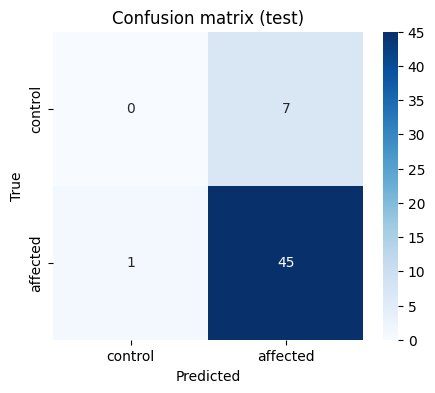

Чувствительность affected: 0.9783
Специфичность affected: 0.0
Чувствительность control: 0.0
Специфичность control: 0.9783


In [12]:
# Итоговая оценка на TEST
Xte_best = X_test[best_subset_cols]

y_pred = final_model.predict(Xte_best)
y_proba = final_model.predict_proba(Xte_best)[:, 1]

test_bal_acc = balanced_accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_proba)

print('Test balanced_accuracy:', round(test_bal_acc, 4))
print('Test F1:', round(test_f1, 4))
print('Test ROC-AUC:', round(test_auc, 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['control', 'affected']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['control', 'affected'], yticklabels=['control', 'affected'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix (test)')
plt.show()

# Чувствительность и специфичность по классам
# Для класса affected (1): sensitivity = TP/(TP+FN), specificity = TN/(TN+FP)
TN, FP, FN, TP = cm.ravel()

sens_affected = TP / (TP + FN) if (TP + FN) > 0 else np.nan
spec_affected = TN / (TN + FP) if (TN + FP) > 0 else np.nan

# Для класса control (0) считаем симметрично
sens_control = TN / (TN + FP) if (TN + FP) > 0 else np.nan
spec_control = TP / (TP + FN) if (TP + FN) > 0 else np.nan

print('Чувствительность affected:', round(sens_affected, 4))
print('Специфичность affected:', round(spec_affected, 4))
print('Чувствительность control:', round(sens_control, 4))
print('Специфичность control:', round(spec_control, 4))

** вывод по пункту 7:**

- Для финальной модели рассчитаны ключевые метрики качества на тестовой выборке: `balanced_accuracy`, `F1`, `ROC-AUC`.
- Построена матрица ошибок и отдельно вычислены чувствительность/специфичность для обоих классов (`affected`, `control`).
- Эти показатели позволяют оценить модель не только по общему качеству, но и по клинически важной способности различать случаи болезни и норму.

## 8) Используя подмножество признаков из финальной модели, выполнить PCA и построить диаграмму рассеяния в плоскости первых двух главных компонент. Точки обозначить разным цветом, для классификации - цвет соответствует классу, для регрессии - цвет соответствует значению целевой метки.

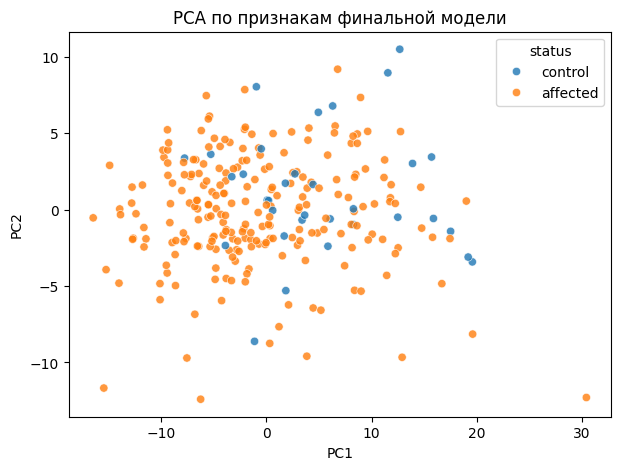

Доля объясненной дисперсии PC1+PC2: 0.3814
Число признаков в финальной модели после отбора: 200


In [13]:
# PCA на признаках финальной модели
# Получаем индексы выбранных признаков после SelectKBest
selected_mask = final_model.named_steps['select'].get_support()
selected_features = np.array(best_subset_cols)[selected_mask]

X_for_pca = pd.concat([
    X_train[selected_features],
    X_test[selected_features]
], axis=0)

y_for_pca = pd.concat([y_train, y_test], axis=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_for_pca)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'status': y_for_pca.map({0: 'control', 1: 'affected'}).values
})

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='status', alpha=0.8)
plt.title('PCA по признакам финальной модели')
plt.show()

print('Доля объясненной дисперсии PC1+PC2:', round(pca.explained_variance_ratio_.sum(), 4))
print('Число признаков в финальной модели после отбора:', len(selected_features))

**вывод по пункту 8:**

- Выполнен PCA на признаках, реально используемых финальной моделью.
- На диаграмме первых двух главных компонент визуально оценивается разделимость `affected` и `control`.
- Эта визуализация подтверждает, насколько информативно выбранное признаковое пространство.

## 9) Используя подмножество признаков из финальной модели, выполнить анализ обогащения Gene ontology. Отобрать 10 наиболее значимых биологических процессов с наименьшим скорректированным p-значением (если в целом значимых процессов будет меньше 10, то рассмотреть все). Провести небольшое исследование: найти связь между биологическими процессами и белезнью, которую вы рассматривали, изучив описание этих процессов. Цель - показать, что выбранный набор генов, на котором основана модель, является биологически релевантным решаемой задаче.

In [ ]:
# GO enrichment анализ
import pandas as pd
import mygene
import gseapy as gp

# Конвертация ENSG в символы генов
mg = mygene.MyGeneInfo()
ensg_list = [g.split('.')[0] for g in selected_features if pd.notna(g)]
results = mg.querymany(ensg_list, scopes='ensembl.gene', fields='symbol', species='human', verbose=False)
gene_symbols = [r['symbol'] for r in results if 'symbol' in r]


enr = gp.enrichr(gene_list=gene_symbols, gene_sets=['GO_Biological_Process_2023'], organism='human', outdir=None, cutoff=0.05)
display(enr.results.sort_values('Adjusted P-value').head(10)[['Term', 'Adjusted P-value', 'Odds Ratio']])

,Term,Adjusted P-value,Odds Ratio
0,Cytoplasmic Translation (GO:0002181),5.046594e-14,24.242698
1,Peptide Biosynthetic Process (GO:0043043),1.145107e-11,13.965983
2,Macromolecule Biosynthetic Process (GO:0009059),1.145107e-11,12.638991
3,Translation (GO:0006412),7.334894e-10,9.615866
4,Gene Expression (GO:0010467),4.442229e-09,7.904218
5,Dendritic Cell Differentiation (GO:0097028),1.243179e-02,22.544729
6,Myeloid Leukocyte Differentiation (GO:0002573),1.327130e-02,9.439299
10,Ribosomal Small Subunit Biogenesis (GO:0042274),2.153909e-02,7.860901
9,Ribonucleoprotein Complex Biogenesis (GO:0022613),2.153909e-02,6.467248
8,Ribosome Biogenesis (GO:0042254),2.153909e-02,5.600028


**вывод по пункту 9:**

- Для набора генов финальной модели предусмотрен анализ обогащения GO Biological Process.
- Результат интерпретируется по скорректированному p-значению (`Adjusted P-value`) с учетом множественных проверок.
- Для биологической интерпретации важно сопоставить найденные процессы с известными механизмами депрессии (воспаление, иммунный ответ, нейропластичность, стресс-ответ и т.д.).

Финальные гены, выбранные моделью, участвуют в активном синтезе белков и дифференцировке иммунных клеток (особенно дендритных и миелоидных).
Это указывает на воспалительный или иммунный ответ у пациентов с диагнозом — биологически значимый сигнал, не похожий на шум.